In [1]:
import os
os.chdir("../")

from dotenv import load_dotenv
load_dotenv()
os.environ["WANDB_API_KEY"] = os.getenv("WANDB_API_KEY")

In [2]:
from ppm.wandb_utils import load_multiple_experiments
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="ticks", font="serif")

In [3]:
PROJECTS = ["exp_001", "exp_002", "exp_003", "exp_004", "exp_005"]
runs, history = load_multiple_experiments(PROJECTS, force_update=False)

runs["lr_str"] = runs["lr"].apply(lambda x: f"{x:.0e}")
runs["dataset_size"] = (
    runs["dataset/train_events"].fillna(0) + 
    runs["dataset/val_events"].fillna(0) + 
    runs["dataset/test_events"].fillna(0)
)

print(f"{len(runs)} runs loaded")

Database already exists: /Users/privat/Documents/PrivateStuff/Uni/BPM_DomainAdaptation/metrics/exp_001.db
Use force_update=True to re-fetch from wandb
Database already exists: /Users/privat/Documents/PrivateStuff/Uni/BPM_DomainAdaptation/metrics/exp_002.db
Use force_update=True to re-fetch from wandb
Database already exists: /Users/privat/Documents/PrivateStuff/Uni/BPM_DomainAdaptation/metrics/exp_003.db
Use force_update=True to re-fetch from wandb
Database already exists: /Users/privat/Documents/PrivateStuff/Uni/BPM_DomainAdaptation/metrics/exp_004.db
Use force_update=True to re-fetch from wandb
Database already exists: /Users/privat/Documents/PrivateStuff/Uni/BPM_DomainAdaptation/metrics/exp_005.db
Use force_update=True to re-fetch from wandb
Loaded 335 runs from 5 experiments
Datasets: ['BPI12', 'BPI17', 'BPI20PrepaidTravelCosts', 'BPI20TravelPermitData', 'BPI20RequestForPayment', 'BPI15', 'BPI19']
335 runs loaded


## 1. 2D Heatmap

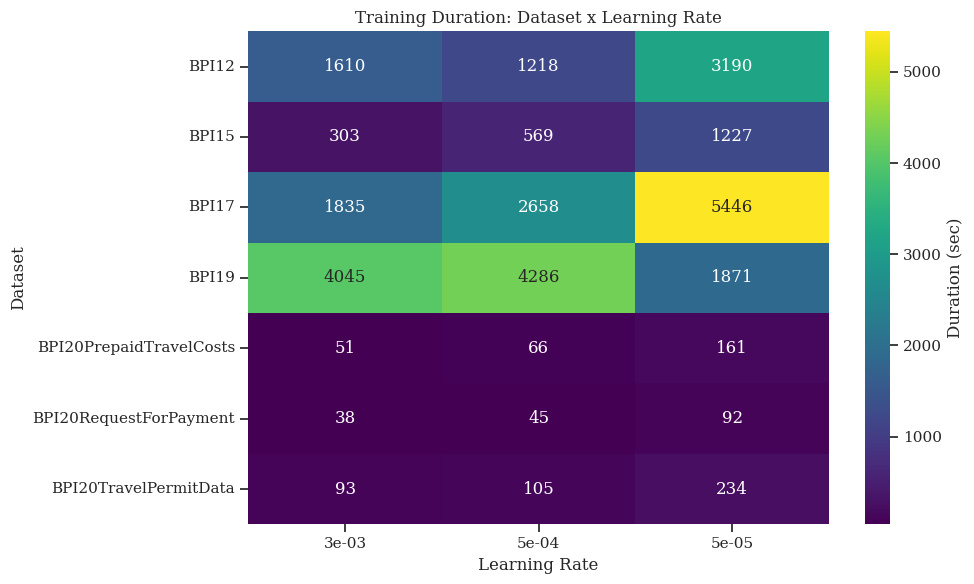

In [4]:
pivot = runs.groupby(["log", "lr_str"])["duration_sec"].mean().unstack()

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="viridis", ax=ax, cbar_kws={"label": "Duration (sec)"})
ax.set_title("Training Duration: Dataset x Learning Rate")
ax.set_xlabel("Learning Rate")
ax.set_ylabel("Dataset")
plt.tight_layout()

## 2. Faceted Plots (Small Multiples)

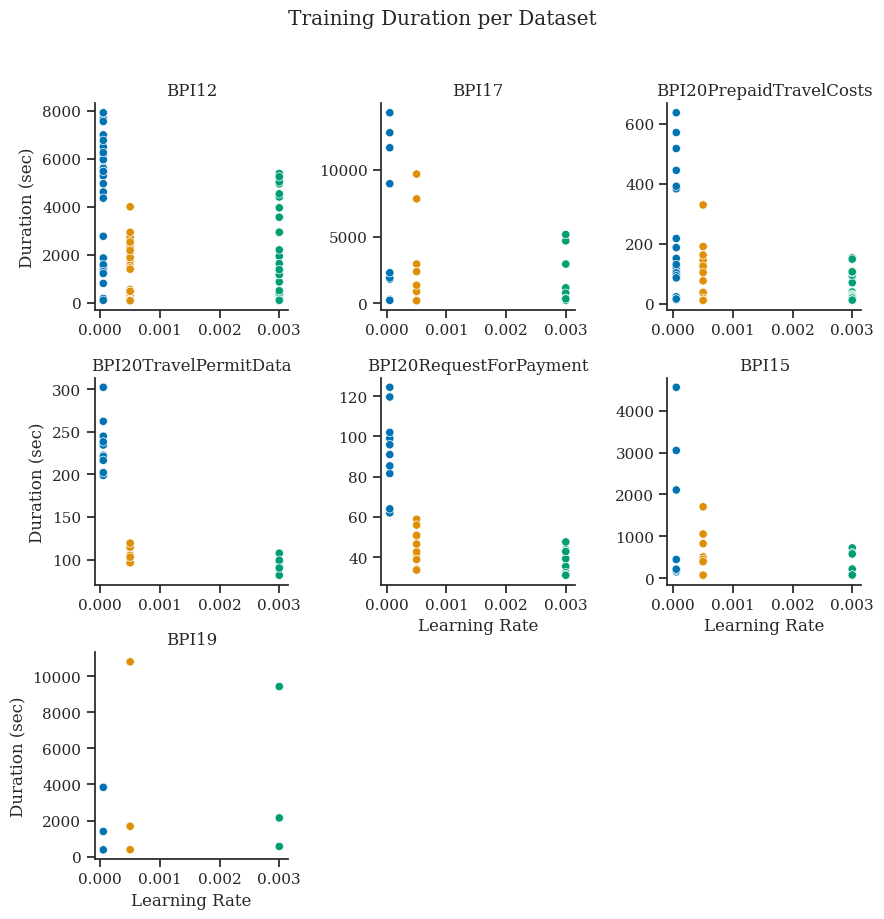

In [5]:
g = sns.FacetGrid(runs, col="log", col_wrap=3, height=3, sharex=False, sharey=False)
g.map_dataframe(sns.scatterplot, x="lr", y="duration_sec", hue="lr_str", palette="colorblind", legend=False)
g.set_titles("{col_name}")
g.set_axis_labels("Learning Rate", "Duration (sec)")
g.figure.suptitle("Training Duration per Dataset", y=1.02)
plt.tight_layout()

## 3. Bubble Chart

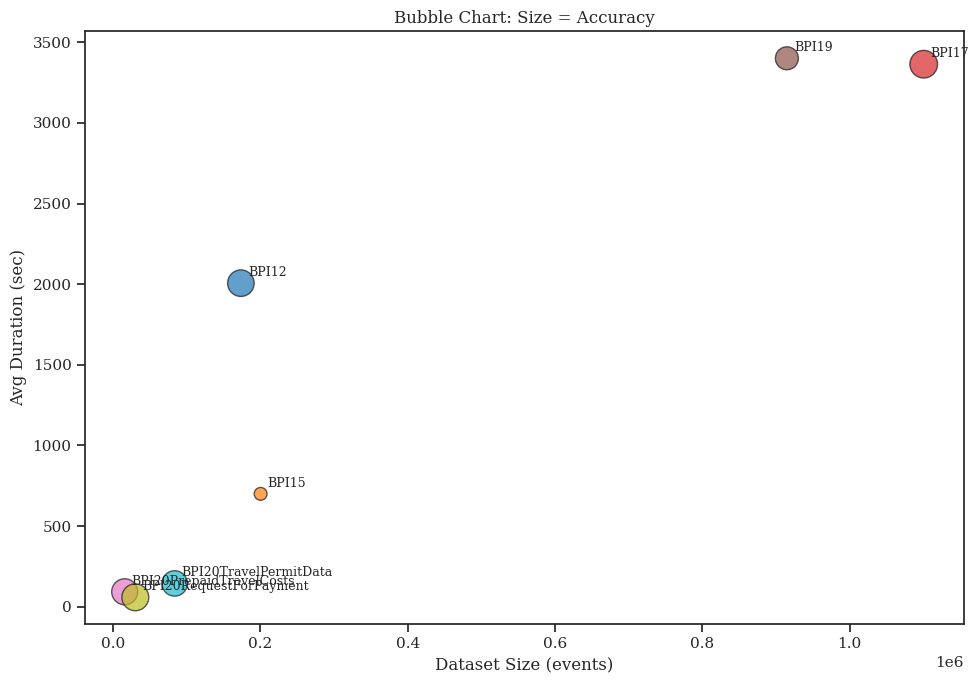

In [6]:
agg = runs.groupby("log").agg({
    "dataset_size": "first",
    "duration_sec": "mean",
    "best_test_final_next_activity_acc": "mean",
}).reset_index()

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    agg["dataset_size"], 
    agg["duration_sec"], 
    s=agg["best_test_final_next_activity_acc"] * 500,
    c=range(len(agg)),
    cmap="tab10",
    alpha=0.7,
    edgecolors="k",
)

for i, row in agg.iterrows():
    ax.annotate(row["log"], (row["dataset_size"], row["duration_sec"]), 
                textcoords="offset points", xytext=(5, 5), fontsize=9)

ax.set_xlabel("Dataset Size (events)")
ax.set_ylabel("Avg Duration (sec)")
ax.set_title("Bubble Chart: Size = Accuracy")
plt.tight_layout()

## 4. Contour Plot

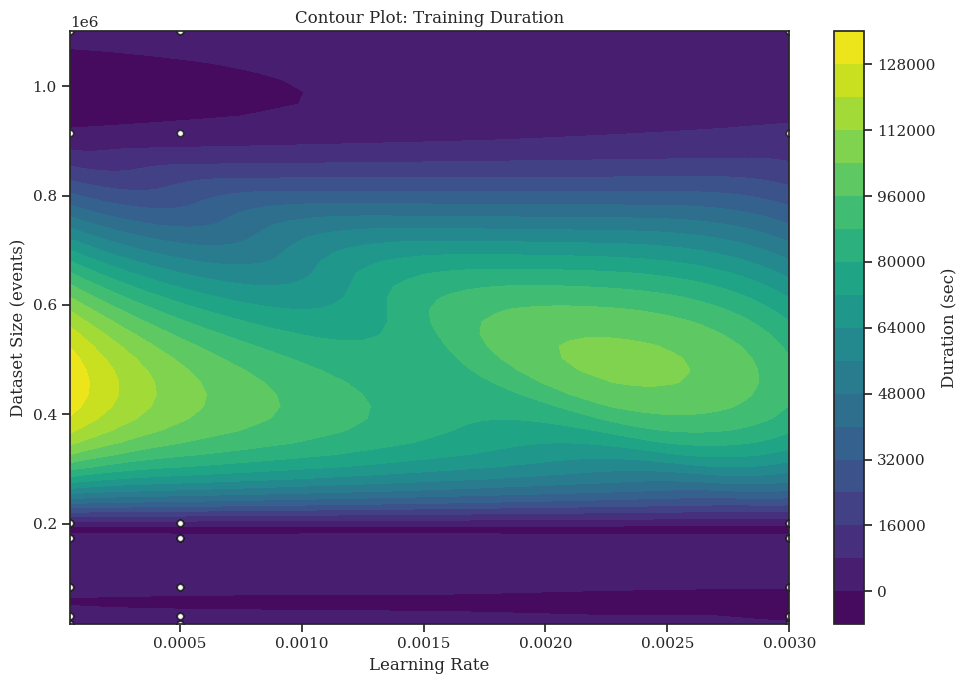

In [7]:
from scipy.interpolate import griddata

x = runs["lr"].values
y = runs["dataset_size"].values
z = runs["duration_sec"].values

xi = np.linspace(x.min(), x.max(), 50)
yi = np.linspace(y.min(), y.max(), 50)
xi, yi = np.meshgrid(xi, yi)

try:
    zi = griddata((x, y), z, (xi, yi), method="cubic")
    
    fig, ax = plt.subplots(figsize=(10, 7))
    contour = ax.contourf(xi, yi, zi, levels=20, cmap="viridis")
    ax.scatter(x, y, c="white", s=20, edgecolors="k", alpha=0.7)
    plt.colorbar(contour, ax=ax, label="Duration (sec)")
    ax.set_xlabel("Learning Rate")
    ax.set_ylabel("Dataset Size (events)")
    ax.set_title("Contour Plot: Training Duration")
    plt.tight_layout()
except Exception as e:
    print(f"Contour plot failed: {e}")

## 5. 3D Plot: Training Duration (Scatter Only)

In [ ]:
from visualization.visualization import plot_3d_manifold, PlotConfig

fig_3d = plot_3d_manifold(
    runs,
    x="lr",
    y="dataset_size",
    z="duration_sec",
    color="log",
    config=PlotConfig(
        figsize=(10, 8),
        title="Training Duration (Scatter Only)",
        xlabel="Learning Rate",
        ylabel="Dataset Size (events)",
    ),
    manifold=False,
    scatter=True,
)

## 6. 3D Plot: Training Duration (with Manifold Surface)

In [ ]:
fig_3d_manifold = plot_3d_manifold(
    runs,
    x="lr",
    y="dataset_size",
    z="duration_sec",
    color="log",
    config=PlotConfig(
        figsize=(10, 8),
        title="Training Duration (with Manifold Surface)",
        xlabel="Learning Rate",
        ylabel="Dataset Size (events)",
    ),
    manifold=True,
    scatter=True,
)